In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors,datasets

In [18]:
#导入并整理数据
iris = datasets.load_iris()
X = iris.data[:,:2]
#提取分类标签
y = iris.target

In [20]:
#创建了预测分类的查询点
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1,xx2 = np.meshgrid(x1_array,x2_array)

In [24]:
#创建色谱
rgb = [[255,238,255],
       [219,238,244],
       [228,228,228]]
#转换为0-1的浮点数,带.表示浮点数
rgb = np.array(rgb)/255.
#创建离散色谱 ,可视化为区域背景色
#提供颜色映射表,根据分类和数值填充颜色区域,数值必须与颜色对应,自动填充
#再绘图阶段,matplotlib这里支持使用Z的索引取得的数字值对应cmap导入的色谱实参进行生成颜色二维表格用于渲染
cmap_light = ListedColormap(rgb)
cmap_bold = [[255,51,0],
             [0,153,255],
             [138,138,138]]
#强调色,直接用于点的原色选取,不需要映射整张区域
#是一个numpy数组,不是colormap对象
cmap_bold = np.array(cmap_bold)/255.

In [40]:
k_neighbors = 4#临近数量为4
#创建分类器对象kNN 指定了算法使用最近邻居数量
kNN = neighbors.KNeighborsClassifier(k_neighbors)
kNN.fit(X,y)

KNeighborsClassifier(n_neighbors=4)

In [42]:
#内部展平成一维数组,然后按列合并 形状为n行2列
q = np.c_[xx1.ravel(),xx2.ravel()]
#用knn对一系列查询点进行预测
y_predict = kNN.predict(q)
#再将形状恢复为二维数组
y_predict = y_predict.reshape(xx1.shape)

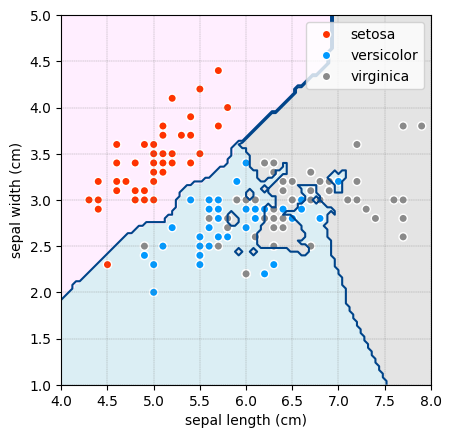

In [54]:
#可视化
fig,ax = plt.subplots()
#函数名中的f表示filled满的)
plt.contourf(xx1,xx2,y_predict,cmap = cmap_light)
plt.contour(xx1,xx2,y_predict,levels = [0,1,2],#
            colors = np.array([0,68,138])/255.)
sns.scatterplot(x = X[:,0],y = X[:,1],
                hue = iris.target_names[y],
                ax = ax,
                #指定每个分类标签的颜色
                palette = dict(setosa = cmap_bold[0,:],
                               versicolor = cmap_bold[1,:],
                               virginica = cmap_bold[2,:]),
                alpha = 1.0,
                linewidth = 1,edgecolor = [1,1,1])
plt.xlim(4,8);plt.ylim(1,5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle = '--',linewidth = 0.25,
        color = [0.5,0.5,0.5])
ax.set_aspect('equal',adjustable = 'box')

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors,datasets

In [60]:
iris = datasets.load_iris()
X = iris.data[:,:2]
y = iris.target

In [62]:
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1,xx2 = np.meshgrid(x1_array,x2_array)

In [64]:
rgb = [[255,238,255],
       [219,238,244],
       [228,228,228]]
rgb = np.array(rgb)/255.
cmap_light = ListedColormap(rgb)
cmap_bold = [[255,51,0],
             [0,153,255],
             [138,138,138]]
cmap_bold = np.array(cmap_bold)/255.

In [116]:
from sklearn.naive_bayes import GaussianNB
#创建高斯朴素贝叶斯分类器对象
gnb = GaussianNB()
gnb = gnb.fit(X,y)
#用高斯朴素贝叶斯分类器对一系列点进行预测
q = np.c_[xx1.ravel(),xx2.ravel()]
y_predict = gnb.predict(q)
y_predict = y_predict.reshape(xx1.shape)
y_predict

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2]])

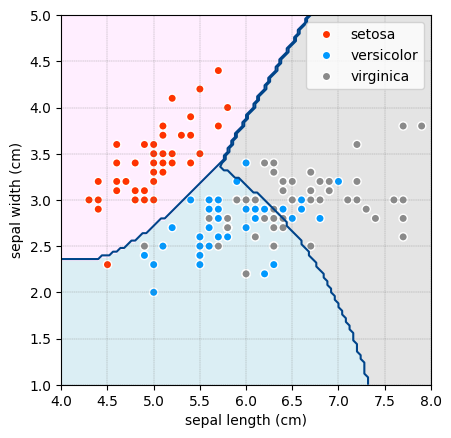

In [152]:
#可视化
fig,ax = plt.subplots()
plt.contourf(xx1,xx2,y_predict,cmap = cmap_light)
#理念是即是哪里恰好穿过给的level值,按照大小来定
plt.contour(xx1,xx2,y_predict,levels = [0,1,2],
             colors = np.array([0,68,138])/255.)
sns.scatterplot(x = X[:,0],y = X[:,1],
                #取出花朵名称 给hue用来按照这些花朵名称上不同颜色,然后对照palette上色
                #实参hue接受标签后进行上色,如果给了palette按照这个上色,如果没给,将按照默认调色板上色
                hue = iris.target_names[y],
                ax = ax,
                #参数可以是cmap也可以是字典,这里根据字典分配颜色
                #管理三种标签后进行配色
                palette = dict(setosa = cmap_bold[0,:],
                                versicolor = cmap_bold[1,:],
                                virginica = cmap_bold[2,:]),
                #透明度
                alpha = 1.0,
                linewidth = 1,edgecolor = [1,1,1])
plt.xlim(4,8);plt.ylim(1,5)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle = '--',linewidth = 0.25,
        color = [0.5,0.5,0.5])
#aspect表示横纵比
ax.set_aspect('equal',adjustable = 'box')

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn import neighbors,datasets

In [158]:
iris = datasets.load_iris()
X = iris.data[:,:2]
y = iris.target

In [160]:
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1,xx2 = np.meshgrid(x1_array,x2_array)

In [168]:
rgb = [[255,238,255],
       [219,238,244],
       [228,228,228]]
rgb = np.array(rgb)/255.
#创建离散色谱,表示颜色是一格一格分开的,是固定颜色,无渐变
cmap_light = ListedColormap(rgb)
cmap_blod = [[255,51,0],
             [0,153,255],
             [138,138,138]]
cmap_bold = np.array(cmap_blod)/255.